In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Plot style
plt.style.use('default')

In [2]:
df = pd.read_csv("../data/mia_flights_clean.csv")

features = [
    'dep_time',
    'taxi_out',
    'taxi_in',
    'air_time',
    'distance',
    'weather_delay',
    'late_aircraft_delay'
]
X = df[features]

X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

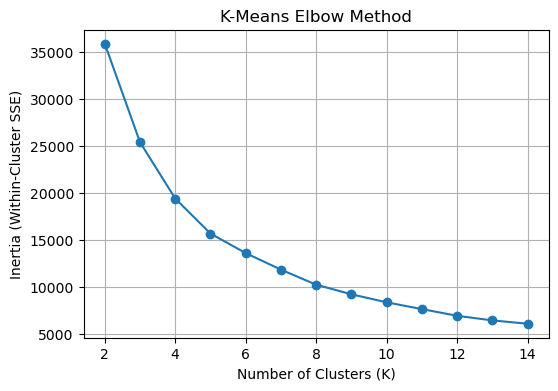

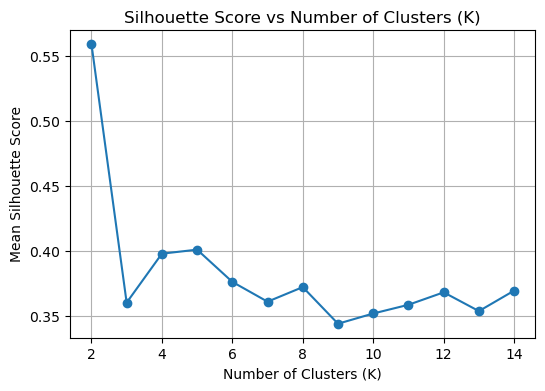

In [3]:
inertia, sil, K_range = [], [], range(2, 15)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, labels_k))

plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertia, 'o-')
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil, 'o-')
plt.title("Silhouette Score vs Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Mean Silhouette Score")
plt.grid(True)
plt.show()

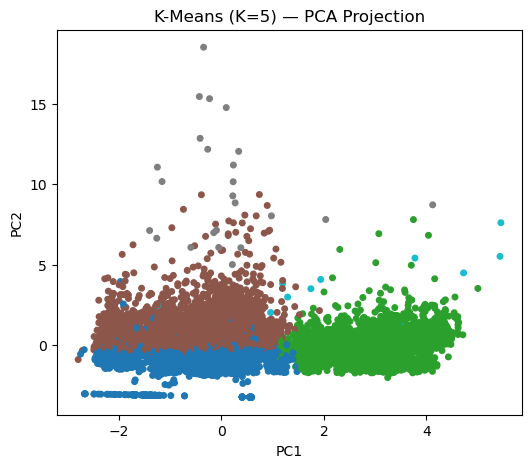

Silhouette Score (K-Means, K=5): 0.237


In [4]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, s=16, cmap='tab10')
plt.title("K-Means (K=5) — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Silhouette Score (K-Means, K=5):", round(silhouette_score(X_scaled, labels_km), 3))

In [5]:
df['cluster'] = labels_km
df.groupby('cluster')[features].mean()

,dep_time,taxi_out,taxi_in,air_time,distance,weather_delay,late_aircraft_delay
cluster,,,,,,,
0,1024.802412,19.525756,8.095016,129.687150,935.975421,0.226783,2.329152
1,1407.279687,22.351172,9.101562,307.321484,2199.078516,0.385547,6.004297
2,1894.100517,24.409229,8.626027,124.385467,882.229111,0.500786,11.351415
3,1655.083333,24.083333,9.333333,160.250000,1140.041667,1.958333,822.291667
4,615.466667,26.666667,8.266667,191.466667,1363.733333,513.666667,49.533333


-1      202
 0    19135
 1       34
 2       11
 3       14
Name: count, dtype: int64


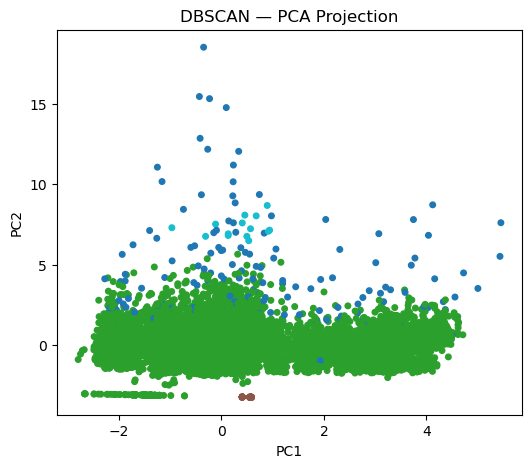

Unique labels: [-1  0  1  2  3]
Silhouette Score (DBSCAN): 0.328


In [14]:
# Run DBSCAN on scaled original features
db = DBSCAN(eps=1.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)

# Save labels
df['db_cluster'] = labels_db

# Counts
print(pd.Series(labels_db).value_counts().sort_index())

# Plot using PCA coordinates
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, s=16, cmap='tab10')
plt.title("DBSCAN — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Silhouette score only if valid
unique_labels = np.unique(labels_db)
non_noise_clusters = [x for x in unique_labels if x != -1]

print("Unique labels:", unique_labels)

if len(non_noise_clusters) >= 2:
    mask = labels_db != -1
    print(
        "Silhouette Score (DBSCAN):",
        round(silhouette_score(X_scaled[mask], labels_db[mask]), 3)
    )
else:
    print("Silhouette Score (DBSCAN): undefined (fewer than 2 non-noise clusters)")

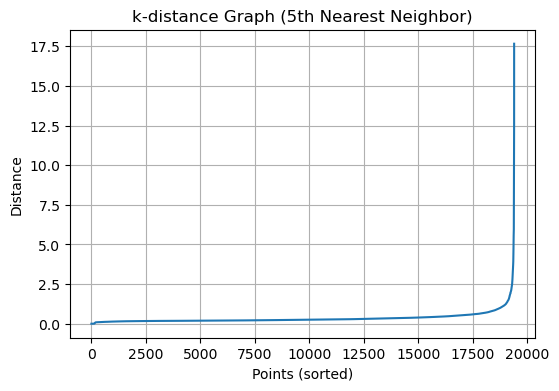

In [7]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kdist = np.sort(distances[:,4])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.title("k-distance Graph (5th Nearest Neighbor)")
plt.xlabel("Points (sorted)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [15]:
df[df['db_cluster'] == -1][features].mean()

dep_time               1405.202970
taxi_out                 40.050000
taxi_in                  18.690000
air_time                170.887179
distance               1256.980198
weather_delay            62.099010
late_aircraft_delay     184.004950
dtype: float64